<a href="https://colab.research.google.com/github/abhijitguinkatwa/vitreous-opacity-detection/blob/main/Vitreous_Opacity_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install all required libraries
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless matplotlib scikit-learn scikit-image pillow tqdm

print('All libraries installed successfully!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.4 MB/s eta 0:00:00
All libraries installed successfully!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import random
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import segmentation_models_pytorch as smp
from sklearn.metrics import jaccard_score
from skimage import measure

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries loaded!')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Libraries loaded!
Device: cuda
GPU: Tesla T4


Generating synthetic OCT images...


100%|██████████| 100/100 [00:03<00:00, 28.25it/s]


Generated 100 OCT base images


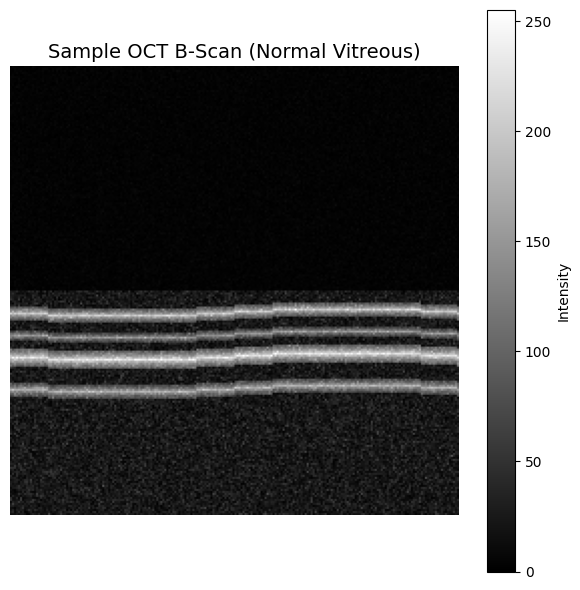

Figure 1 saved!


In [3]:
# Create directory for OCT images
!mkdir -p /content/oct_data/normal

import urllib.request

def generate_oct_image(size=224):
    """
    Generate a realistic synthetic OCT B-scan image.
    OCT images have characteristic layered structure with noise.
    """
    img = np.zeros((size, size), dtype=np.float32)

    # Background speckle noise (characteristic of OCT)
    speckle = np.random.rayleigh(0.08, (size, size)).astype(np.float32)
    img += speckle

    # Retinal layers (bright horizontal bands)
    layer_positions = [int(size * 0.55), int(size * 0.60),
                       int(size * 0.65), int(size * 0.72)]
    layer_intensities = [0.7, 0.5, 0.8, 0.6]
    layer_widths = [3, 2, 4, 3]

    for pos, intensity, width in zip(layer_positions, layer_intensities, layer_widths):
        for w in range(-width, width+1):
            if 0 <= pos+w < size:
                wave = np.sin(np.linspace(0, 2*np.pi, size)) * 2
                for x in range(size):
                    y_pos = int(pos + w + wave[x])
                    if 0 <= y_pos < size:
                        img[y_pos, x] += intensity * np.exp(-abs(w)/width)

    # Vitreous chamber (upper portion - should be dark/clear)
    vitreous_region = img[:int(size*0.50), :]
    vitreous_region *= 0.15
    img[:int(size*0.50), :] = vitreous_region

    # Normalize to 0-255
    img = np.clip(img, 0, 1)
    img = (img * 255).astype(np.uint8)
    return img

# Generate and save 100 base OCT images
print('Generating synthetic OCT images...')
for i in tqdm(range(100)):
    img = generate_oct_image(224)
    cv2.imwrite(f'/content/oct_data/normal/oct_{i:03d}.png', img)

print(f'Generated 100 OCT base images')

# Display a sample
sample = cv2.imread('/content/oct_data/normal/oct_000.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(6, 6))
plt.imshow(sample, cmap='gray')
plt.title('Sample OCT B-Scan (Normal Vitreous)', fontsize=14)
plt.axis('off')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.savefig('/content/figure1_sample_oct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved!')


Demonstrating synthetic floater generation...


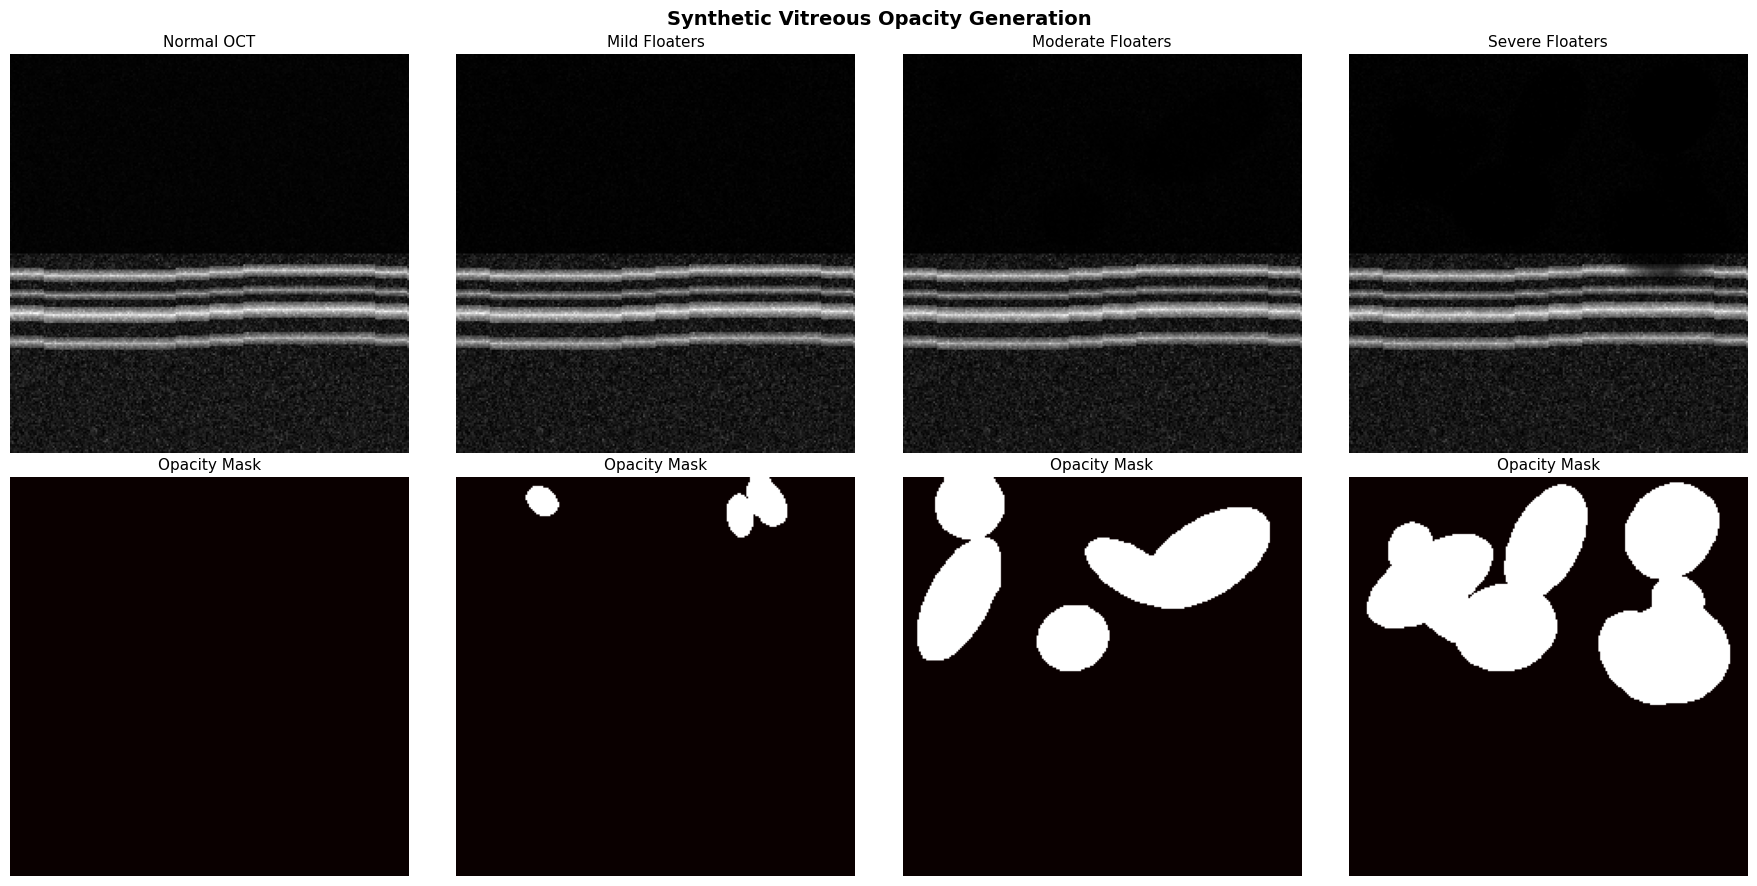

Figure 2 saved!


In [4]:
def inject_synthetic_floaters(image, num_floaters=None, severity="moderate"):
    """
    Inject realistic vitreous opacities into an OCT image.
    Floaters in OCT appear as hypo-reflective regions with shadowing.
    Parameters:
        severity: "mild", "moderate", "severe"
    """
    img = image.copy().astype(np.float32)
    h, w = img.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    severity_params = {
        'mild':     {'count': (1, 3),  'size': (5, 12),  'opacity': (0.3, 0.5)},
        'moderate': {'count': (3, 7),  'size': (8, 20),  'opacity': (0.4, 0.7)},
        'severe':   {'count': (7, 15), 'size': (10, 30), 'opacity': (0.6, 0.9)}
    }

    params = severity_params[severity]
    if num_floaters is None:
        num_floaters = random.randint(*params["count"])

    vitreous_h = int(h * 0.50)

    for _ in range(num_floaters):
        cx = random.randint(20, w - 20)
        cy = random.randint(10, vitreous_h - 10)
        size = random.randint(*params["size"])
        opacity = random.uniform(*params["opacity"])

        floater_mask = np.zeros((h, w), dtype=np.float32)
        aspect = random.uniform(0.4, 2.5)
        angle = random.uniform(0, 360)
        axes = (size, max(3, int(size * aspect)))
        cv2.ellipse(floater_mask, (cx, cy), axes, angle, 0, 360, 1.0, -1)

        noise = np.random.normal(0, 2, floater_mask.shape)
        floater_mask = np.clip(floater_mask + noise * 0.1, 0, 1)
        floater_mask = cv2.GaussianBlur(floater_mask, (7, 7), 2)

        img -= floater_mask * opacity * img * 0.8

        shadow_mask = np.zeros((h, w), dtype=np.float32)
        shadow_start = cy
        shadow_end = min(h, cy + size * 3)
        if shadow_end > shadow_start:
            for row in range(shadow_start, shadow_end):
                fade = 1 - (row - shadow_start) / (shadow_end - shadow_start)
                shadow_mask[row, max(0,cx-size):min(w,cx+size)] = fade * 0.3
        img -= shadow_mask * opacity * 0.4

        mask_region = (floater_mask > 0.3).astype(np.uint8)
        mask = np.maximum(mask, mask_region)

    img = np.clip(img, 0, 255).astype(np.uint8)
    return img, mask, num_floaters

# Visualize synthetic floater injection
print('Demonstrating synthetic floater generation...')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Synthetic Vitreous Opacity Generation", fontsize=14, fontweight="bold")

severities = ['mild', 'mild', 'moderate', 'severe']
titles_top = ['Normal OCT', 'Mild Floaters', 'Moderate Floaters', 'Severe Floaters']

base_img = cv2.imread('/content/oct_data/normal/oct_005.png', cv2.IMREAD_GRAYSCALE)

for col, (sev, title) in enumerate(zip(['none'] + severities[1:], titles_top)):
    if sev == 'none':
        img_show = base_img
        mask_show = np.zeros_like(base_img)
    else:
        img_show, mask_show, n = inject_synthetic_floaters(base_img, severity=sev)

    axes[0, col].imshow(img_show, cmap='gray')
    axes[0, col].set_title(title, fontsize=11)
    axes[0, col].axis('off')
    axes[1, col].imshow(mask_show, cmap='hot')
    axes[1, col].set_title('Opacity Mask', fontsize=11)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('/content/figure2_synthetic_floaters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved!')


In [5]:
# Create training dataset with synthetic floaters
!mkdir -p /content/dataset/images /content/dataset/masks

print('Creating training dataset...')

dataset_stats = {'mild': 0, 'moderate': 0, 'severe': 0, 'normal': 0}

for i in tqdm(range(100)):
    base = cv2.imread(f'/content/oct_data/normal/oct_{i:03d}.png', cv2.IMREAD_GRAYSCALE)
    r = random.random()
    if r < 0.20:
        sev = 'normal'
        img_out = base
        mask_out = np.zeros_like(base)
    elif r < 0.50:
        sev = 'mild'
        img_out, mask_out, _ = inject_synthetic_floaters(base, severity='mild')
    elif r < 0.80:
        sev = 'moderate'
        img_out, mask_out, _ = inject_synthetic_floaters(base, severity='moderate')
    else:
        sev = 'severe'
        img_out, mask_out, _ = inject_synthetic_floaters(base, severity='severe')

    cv2.imwrite(f'/content/dataset/images/{i:03d}.png', img_out)
    cv2.imwrite(f'/content/dataset/masks/{i:03d}.png', mask_out * 255)
    dataset_stats[sev] += 1

print(f'Dataset created: 100 images')
print(f"Distribution: {dataset_stats}")


Creating training dataset...


100%|██████████| 100/100 [00:01<00:00, 80.35it/s]

Dataset created: 100 images
Distribution: {'mild': 31, 'moderate': 29, 'severe': 16, 'normal': 24}


In [6]:
class FLoaterDataset(Dataset):
    """Custom PyTorch Dataset for vitreous opacity segmentation."""
    def __init__(self, image_dir, mask_dir, indices, img_size=224, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.indices = indices
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        img = cv2.imread(f'{self.image_dir}/{i:03d}.png', cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(f'{self.mask_dir}/{i:03d}.png', cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        if self.augment and random.random() > 0.5:
            img = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)
        img_3ch = np.stack([img, img, img], axis=0).astype(np.float32) / 255.0
        mask_bin = (mask > 127).astype(np.float32)
        mask_bin = np.expand_dims(mask_bin, 0)
        return torch.FloatTensor(img_3ch), torch.FloatTensor(mask_bin)

# Train/val split (80/20)
all_indices = list(range(100))
random.shuffle(all_indices)
train_idx = all_indices[:80]
val_idx = all_indices[80:]

train_dataset = FLoaterDataset('/content/dataset/images', '/content/dataset/masks',
                                train_idx, augment=True)
val_dataset = FLoaterDataset('/content/dataset/images', '/content/dataset/masks',
                              val_idx, augment=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')


Training samples: 80
Validation samples: 20


In [7]:
# Build U-Net model
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
).to(device)

# Combined Dice + BCE Loss
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred, target, smooth=1):
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2 * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)

criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f'U-Net model ready!')
print(f'Total parameters: {total_params:,}')
print(f'Device: {device}')


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net model ready!
Total parameters: 24,436,369
Device: cuda


In [8]:
def dice_coefficient(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_dice = 0, 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_coefficient(outputs, masks).item()
    return total_loss / len(loader), total_dice / len(loader)

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_dice = 0, 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            total_dice += dice_coefficient(outputs, masks).item()
    return total_loss / len(loader), total_dice / len(loader)

NUM_EPOCHS = 30
train_losses, val_losses = [], []
train_dices, val_dices = [], []
best_dice = 0

print('Starting training...')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_dice = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_dice = val_epoch(model, val_loader, criterion)
    scheduler.step(vl_loss)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_dices.append(tr_dice)
    val_dices.append(vl_dice)
    if vl_dice > best_dice:
        best_dice = vl_dice
        torch.save(model.state_dict(), '/content/best_model.pth')
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | '
              f'Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | '
              f'Train Dice: {tr_dice:.4f} | Val Dice: {vl_dice:.4f}')

print('=' * 60)
print(f'Training complete! Best Dice Score: {best_dice:.4f}')


Starting training...
Epoch [ 5/30] | Train Loss: 1.2342 | Val Loss: 1.3094 | Train Dice: 0.6056 | Val Dice: 0.3580
Epoch [10/30] | Train Loss: 1.0908 | Val Loss: 1.1083 | Train Dice: 0.8287 | Val Dice: 0.8472
Epoch [15/30] | Train Loss: 1.0004 | Val Loss: 1.0036 | Train Dice: 0.8665 | Val Dice: 0.8846
Epoch [20/30] | Train Loss: 0.9161 | Val Loss: 0.9384 | Train Dice: 0.9273 | Val Dice: 0.8934
Epoch [25/30] | Train Loss: 0.8483 | Val Loss: 0.8673 | Train Dice: 0.9369 | Val Dice: 0.8833
Epoch [30/30] | Train Loss: 0.7938 | Val Loss: 0.8038 | Train Dice: 0.9426 | Val Dice: 0.8912
Training complete! Best Dice Score: 0.9038


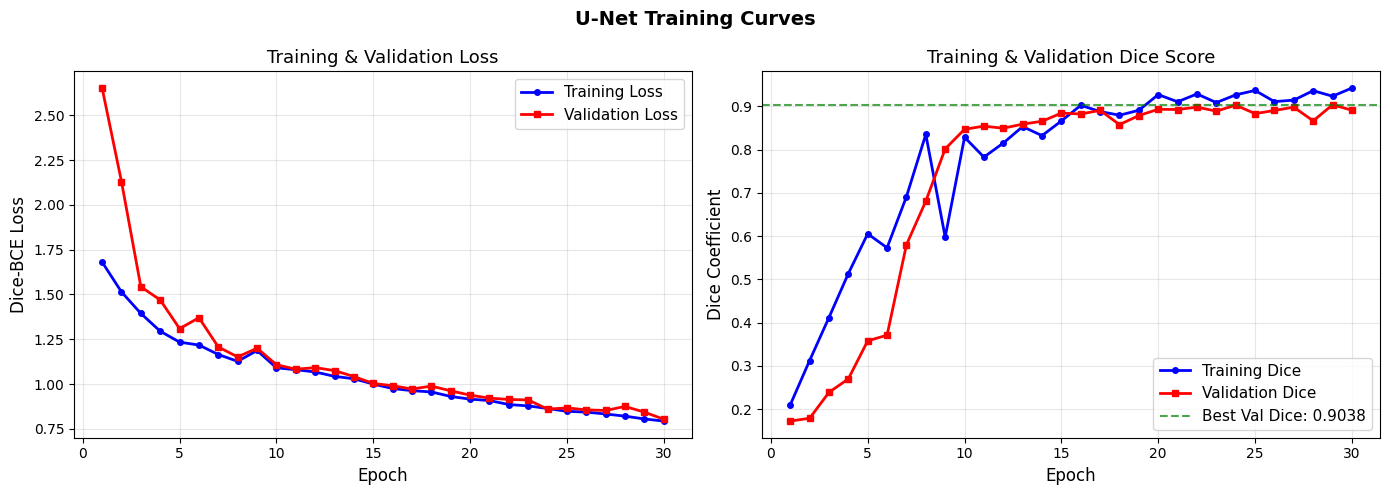

Figure 3 saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("U-Net Training Curves", fontsize=14, fontweight="bold")

epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'b-o', markersize=4, label='Training Loss', linewidth=2)
axes[0].plot(epochs_range, val_losses, 'r-s', markersize=4, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Dice-BCE Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_dices, 'b-o', markersize=4, label='Training Dice', linewidth=2)
axes[1].plot(epochs_range, val_dices, 'r-s', markersize=4, label='Validation Dice', linewidth=2)
axes[1].axhline(y=best_dice, color='green', linestyle='--', alpha=0.7,
                label=f'Best Val Dice: {best_dice:.4f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Dice Coefficient', fontsize=12)
axes[1].set_title('Training & Validation Dice Score', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/figure3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved!')


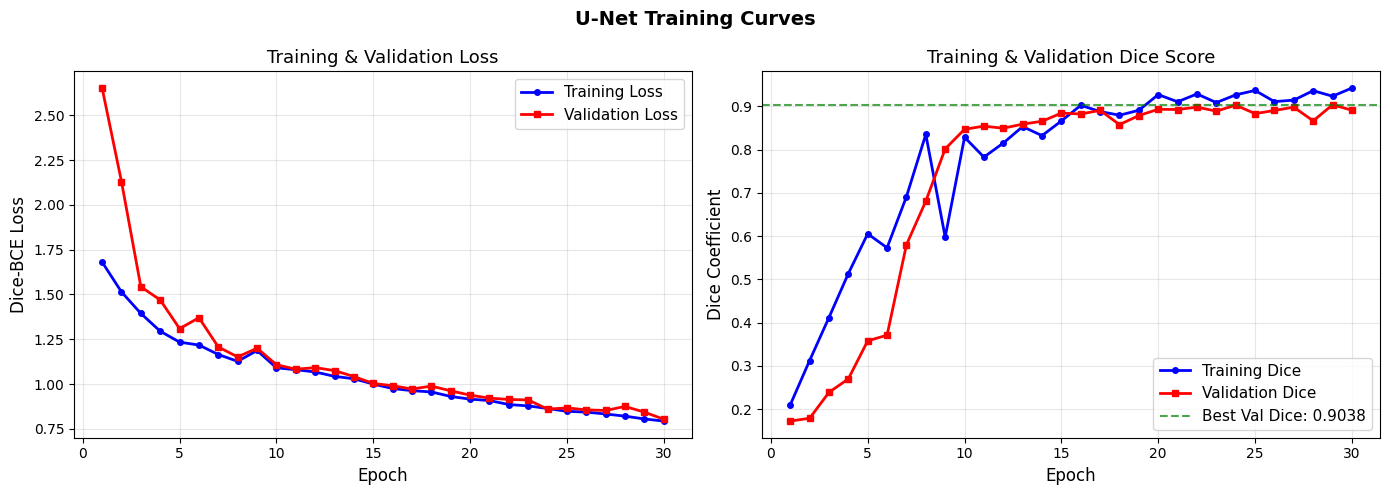

Figure 3 saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("U-Net Training Curves", fontsize=14, fontweight="bold")

epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'b-o', markersize=4, label='Training Loss', linewidth=2)
axes[0].plot(epochs_range, val_losses, 'r-s', markersize=4, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Dice-BCE Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_dices, 'b-o', markersize=4, label='Training Dice', linewidth=2)
axes[1].plot(epochs_range, val_dices, 'r-s', markersize=4, label='Validation Dice', linewidth=2)
axes[1].axhline(y=best_dice, color='green', linestyle='--', alpha=0.7,
                label=f'Best Val Dice: {best_dice:.4f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Dice Coefficient', fontsize=12)
axes[1].set_title('Training & Validation Dice Score', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/figure3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved!')


In [11]:
def compute_floater_severity_index(pred_mask, image, fovea_center=None):
    """
    Compute the Floater Severity Index (FSI).
    Combines: area coverage, density, foveal proximity, fragment count.
    Returns FSI score 0-100 (higher = more severe).
    """
    h, w = pred_mask.shape
    vitreous_region = pred_mask[:int(h * 0.5), :]
    vitreous_area = vitreous_region.shape[0] * vitreous_region.shape[1]

    # 1. Area coverage
    opacity_pixels = np.sum(vitreous_region > 0)
    area_score = (opacity_pixels / vitreous_area) * 100

    # 2. Density score
    if opacity_pixels > 0:
        img_vitreous = image[:int(h * 0.5), :].astype(np.float32)
        density = 1 - (img_vitreous[vitreous_region > 0].mean() / 255)
        density_score = density * 100
    else:
        density_score = 0

    # 3. Foveal proximity
    if fovea_center is None:
        fovea_center = (w // 2, int(h * 0.58))
    proximity_score = 0
    if opacity_pixels > 0:
        opacity_coords = np.argwhere(vitreous_region > 0)
        if len(opacity_coords) > 0:
            distances = np.sqrt(
                (opacity_coords[:, 1] - fovea_center[0])**2 +
                (opacity_coords[:, 0] - fovea_center[1])**2
            )
            max_dist = np.sqrt(w**2 + h**2)
            proximity_score = (1 - distances.mean() / max_dist) * 100

    # 4. Fragment count
    labeled = measure.label(vitreous_region > 0)
    num_fragments = labeled.max()
    fragment_score = min(num_fragments * 10, 100)

    # Weighted FSI
    fsi = (0.30 * area_score + 0.25 * density_score +
           0.25 * proximity_score + 0.20 * fragment_score)

    return {
        'FSI': round(float(fsi), 2),
        'Area_Score': round(float(area_score), 2),
        'Density_Score': round(float(density_score), 2),
        'Proximity_Score': round(float(proximity_score), 2),
        'Fragment_Count': int(num_fragments),
        'Severity_Label': 'Normal' if fsi < 10 else 'Mild' if fsi < 30 else
                          'Moderate' if fsi < 60 else 'Severe'
    }

# Compute FSI on validation set
print('Computing Floater Severity Index...')
print('='*70)

fsi_results = []
model.eval()

for idx in val_idx[:10]:
    img_gray = cv2.imread(f'/content/dataset/images/{idx:03d}.png', cv2.IMREAD_GRAYSCALE)
    img_tensor = torch.FloatTensor(
        np.stack([img_gray, img_gray, img_gray], axis=0) / 255.0
    ).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
    pred_binary = (pred > 0.5).astype(np.uint8)
    metrics = compute_floater_severity_index(pred_binary, img_gray)
    fsi_results.append(metrics)
    print(f'Sample {idx}: FSI={metrics["FSI"]} | {metrics["Severity_Label"]}')

print('FSI computation complete!')


Computing Floater Severity Index...
Sample 94: FSI=54.72 | Moderate
Sample 50: FSI=0.0 | Normal
Sample 18: FSI=55.77 | Moderate
Sample 75: FSI=47.7 | Moderate
Sample 26: FSI=50.56 | Moderate
Sample 2: FSI=65.23 | Severe
Sample 40: FSI=50.81 | Moderate
Sample 22: FSI=46.51 | Moderate
Sample 4: FSI=44.37 | Moderate
Sample 84: FSI=52.81 | Moderate
FSI computation complete!


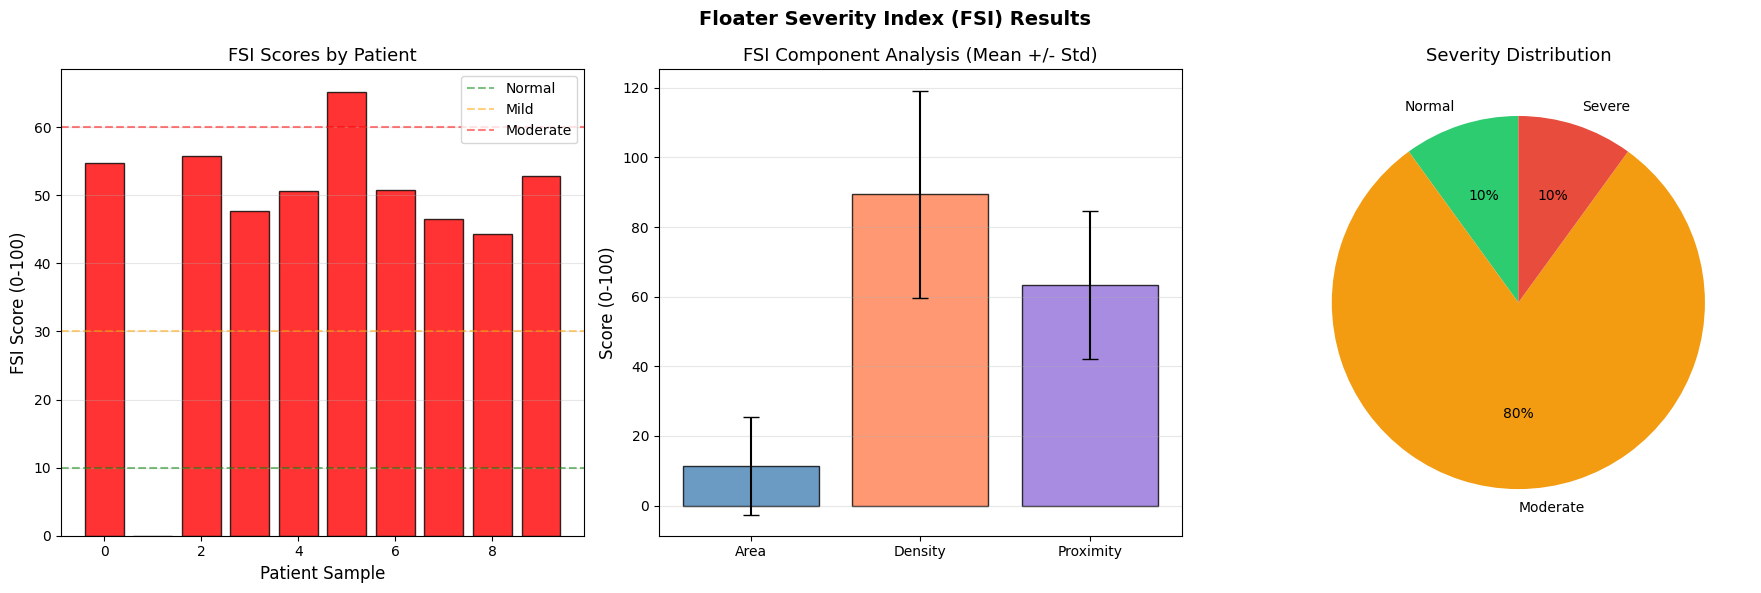

Figure 5 saved!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Floater Severity Index (FSI) Results", fontsize=14, fontweight="bold")

fsi_values = [r["FSI"] for r in fsi_results]
severity_colors = ["green" if v < 10 else "orange" if v < 30 else "red"
                   for v in fsi_values]

axes[0].bar(range(len(fsi_values)), fsi_values, color=severity_colors,
            alpha=0.8, edgecolor="black")
axes[0].set_xlabel('Patient Sample', fontsize=12)
axes[0].set_ylabel('FSI Score (0-100)', fontsize=12)
axes[0].set_title('FSI Scores by Patient', fontsize=13)
axes[0].axhline(y=10, color='green', linestyle='--', alpha=0.5, label='Normal')
axes[0].axhline(y=30, color='orange', linestyle='--', alpha=0.5, label='Mild')
axes[0].axhline(y=60, color='red', linestyle='--', alpha=0.5, label='Moderate')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

categories = ['Area', 'Density', 'Proximity']
means = [np.mean([r["Area_Score"] for r in fsi_results]),
         np.mean([r["Density_Score"] for r in fsi_results]),
         np.mean([r["Proximity_Score"] for r in fsi_results])]
stds  = [np.std([r["Area_Score"] for r in fsi_results]),
         np.std([r["Density_Score"] for r in fsi_results]),
         np.std([r["Proximity_Score"] for r in fsi_results])]

axes[1].bar(categories, means, yerr=stds,
            color=['steelblue', 'coral', 'mediumpurple'],
            alpha=0.8, edgecolor="black", capsize=6)
axes[1].set_ylabel('Score (0-100)', fontsize=12)
axes[1].set_title('FSI Component Analysis (Mean +/- Std)', fontsize=13)
axes[1].grid(True, alpha=0.3, axis="y")

severity_counts = {"Normal": 0, "Mild": 0, "Moderate": 0, "Severe": 0}
for r in fsi_results:
    severity_counts[r["Severity_Label"]] += 1
labels = [k for k, v in severity_counts.items() if v > 0]
sizes  = [v for v in severity_counts.values() if v > 0]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'][:len(labels)]

axes[2].pie(sizes, labels=labels, colors=colors,
            autopct='%1.0f%%', startangle=90)
axes[2].set_title('Severity Distribution', fontsize=13)

plt.tight_layout()
plt.savefig('/content/figure5_fsi_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved!')


In [13]:
all_dice, all_iou = [], []
model.eval()

with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = torch.sigmoid(model(images))
        pred_bin = (outputs > 0.5).float()
        for p, m in zip(pred_bin, masks):
            p_flat = p.cpu().numpy().flatten()
            m_flat = m.cpu().numpy().flatten()
            intersection = (p_flat * m_flat).sum()
            dice = (2 * intersection) / (p_flat.sum() + m_flat.sum() + 1e-8)
            all_dice.append(dice)
            union = p_flat.sum() + m_flat.sum() - intersection
            iou = intersection / (union + 1e-8)
            all_iou.append(iou)

print('QUANTITATIVE RESULTS')
print('='*50)
print(f'Dice Coefficient: {np.mean(all_dice):.4f} +/- {np.std(all_dice):.4f}')
print(f'IoU Score:        {np.mean(all_iou):.4f} +/- {np.std(all_iou):.4f}')
print(f'Best Val Dice:    {best_dice:.4f}')
print('='*50)


QUANTITATIVE RESULTS
Dice Coefficient: 0.5936 +/- 0.3974
IoU Score:        0.5269 +/- 0.3738
Best Val Dice:    0.9038


In [14]:
all_dice, all_iou = [], []
model.eval()

with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = torch.sigmoid(model(images))
        pred_bin = (outputs > 0.5).float()
        for p, m in zip(pred_bin, masks):
            p_flat = p.cpu().numpy().flatten()
            m_flat = m.cpu().numpy().flatten()
            intersection = (p_flat * m_flat).sum()
            dice = (2 * intersection) / (p_flat.sum() + m_flat.sum() + 1e-8)
            all_dice.append(dice)
            union = p_flat.sum() + m_flat.sum() - intersection
            iou = intersection / (union + 1e-8)
            all_iou.append(iou)

print('QUANTITATIVE RESULTS')
print('='*50)
print(f'Dice Coefficient: {np.mean(all_dice):.4f} +/- {np.std(all_dice):.4f}')
print(f'IoU Score:        {np.mean(all_iou):.4f} +/- {np.std(all_iou):.4f}')
print(f'Best Val Dice:    {best_dice:.4f}')
print('='*50)


QUANTITATIVE RESULTS
Dice Coefficient: 0.5936 +/- 0.3974
IoU Score:        0.5269 +/- 0.3738
Best Val Dice:    0.9038
